Valeur estimée par Monte Carlo de l'intégrale de f : 0.1499168919482064
Valeur approchée de zêta(3) : 1.2020569031097323
Valeur estimée de zêta(3) par méthode de Monte-Carlo : 1.1993351355856512
Ecart entre l'estimation et la valeur réelle (somme tronquée à 100 000) : 0.0027217675240811534


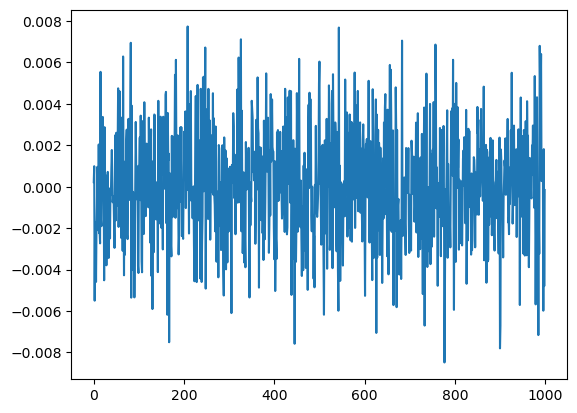

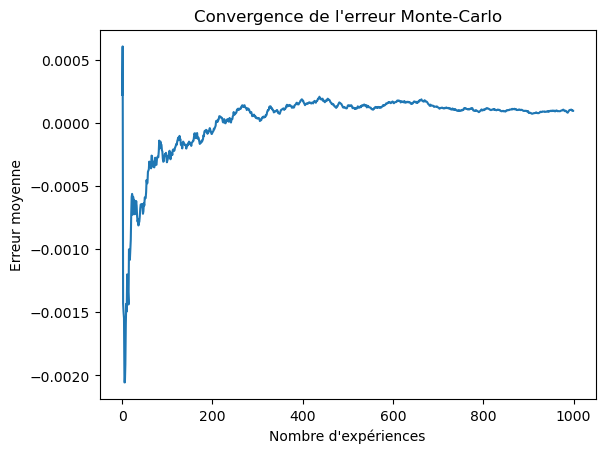

: 

In [ ]:
import numpy as np
import numpy.random as rd
import matplotlib.pyplot as plt

def f(x) : 
    return (np.log(np.sin(x))*np.log(np.cos(x)))/np.tan(x)

# On sait que l'intégrale de f fait zeta(3)/8
# On va l'utiliser pour calculer la valeur de zeta(3)

def par_Monte_Carlo() :
    a=0
    for i in range(100000) :
        u = rd.random()
        u *= np.pi/2
        a += f(u)
    a = a*np.pi/200000
    return a

par_monte_carlo = par_Monte_Carlo()
print(f"Valeur estimée par Monte Carlo de l'intégrale de f : {par_monte_carlo}")

def par_calcul_de_la_serie() :
    b = 0
    for i in range(100000) :
        b += 1/((i+1)**3)
    return b

par_calcul = par_calcul_de_la_serie()
print(f"Valeur approchée de zêta(3) : {par_calcul}")

print(f"Valeur estimée de zêta(3) par méthode de Monte-Carlo : {8*par_monte_carlo}")

print(f"Ecart entre l'estimation et la valeur réelle (somme tronquée à 100 000) : {par_calcul - 8*par_monte_carlo}")

liste_ecarts = []
for i in range(1000) :
    liste_ecarts.append(par_calcul - 8*par_Monte_Carlo())
    if i % 50 == 0 :
        print(f"{i} itérations faites")

plt.plot(liste_ecarts)
plt.show()

moyennes = np.cumsum(liste_ecarts) / np.arange(1, len(liste_ecarts) + 1)

plt.plot(moyennes)
plt.xlabel("Nombre d'expériences")
plt.ylabel("Erreur moyenne")
plt.title("Convergence de l'erreur Monte-Carlo")
plt.show()